<a href="https://colab.research.google.com/github/BrunoCapron/ESQ724-fundamentos_aprendizado_maquina/blob/main/Redes_Neuronais/MLP_regressao.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Consideramos novamente o problema de predição do valor de casas na California, usando uma versão simplificada do conjunto de dados imobiliários sobre distritos da California. Neste conjunto, só há atributos numéricos e não tem dados faltantes.

Carregamos o conjunto de dados e criamos os conjuntos de dados de treinamento,  validação e teste:

In [ ]:
import os
print(os.getcwd())

/content


In [ ]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

housing = fetch_california_housing()
X_train_full, X_test, y_train_full, y_test = train_test_split(
housing.data, housing.target)
X_train, X_valid, y_train, y_valid = train_test_split(
X_train_full, y_train_full)
scaler = StandardScaler() #os dados são padronizados
X_train = scaler.fit_transform(X_train)
X_valid = scaler.transform(X_valid)
X_test = scaler.transform(X_test)

Criamos uma MLP com uma camada escondida de 30 neurônios e função de ativação ReLU e uma camada de saída com um neurônio (queremos predizer um único valor)

In [ ]:
import tensorflow as tf
from tensorflow import keras

model = keras.models.Sequential([
keras.layers.Dense(30, activation="relu", input_shape=X_train.shape[1:]),  #ou sem especificar a dimensão da entrada: keras.layers.Dense(1, activation="relu"),
keras.layers.Dense(1)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Definimos a função perda e o otimizador a ser utilizado:

In [ ]:
model.compile(loss="mean_squared_error", optimizer="sgd")

Treinamos agora a MLP em cima dos dados de treinamento com validação sobre os dados de validação:

In [ ]:
history = model.fit(X_train, y_train, epochs=100,
validation_data=(X_valid, y_valid))

Epoch 1/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.3301 - val_loss: 0.5592
Epoch 2/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6111 - val_loss: 0.5113
Epoch 3/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4655 - val_loss: 0.4869
Epoch 4/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4508 - val_loss: 0.4818
Epoch 5/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4563 - val_loss: 0.4681
Epoch 6/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4288 - val_loss: 0.4610
Epoch 7/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4285 - val_loss: 0.4523
Epoch 8/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4141 - val_loss: 0.4482
Epoch 9/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4148 - val_loss: 0.4461
Epoch 10/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3912 - val_loss: 0.4430
Epoch 11/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3882 - val_loss: 0.4341
Epoch 12/100
363/363 ━━━━━━━━━━━━━━━━━━━━

plotamos o mse de treinamento e de validação em função do número de épocas.

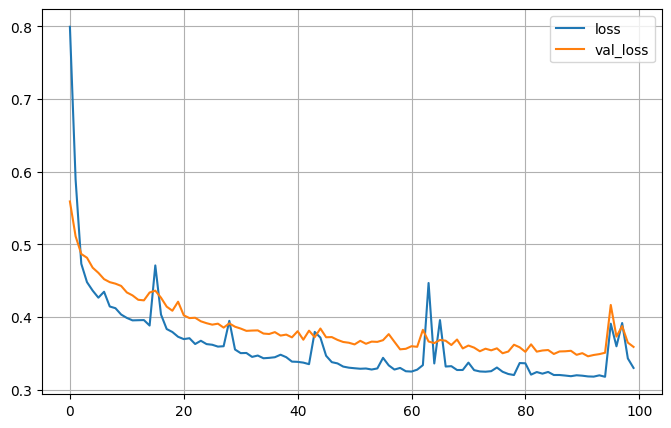

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
#plt.gca().set_ylim(0, 2) # set the vertical range to [0-1]
plt.show()

Avaliamos o modelo em cima dos dados de teste:

In [ ]:
mse_test = model.evaluate(X_test, y_test)

162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3257


Pode-se salvar o modelo através de:

In [ ]:
model.save("my_keras_model.keras")

E recarregá-lo através de:

In [ ]:
model2 = keras.models.load_model("my_keras_model.keras")

Usamos o modelo para predição:

In [ ]:
X_new = X_test[:3]
y_pred = model.predict(X_new)
print('valores preditos:')
print(y_pred)
print('valores reais:')
print(y_test[:3])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
valores preditos:
[[2.2266603]
 [3.2747366]
 [3.3638058]]
valores reais:
[2.823 1.742 4.188]


Usando Callback e salvando o melhor modelo durante o treinamento:

In [ ]:
model3 = keras.models.Sequential([
keras.layers.Dense(30, activation="relu", input_shape=X_train.shape[1:]),  #ou sem especificar a dimensão da entrada: keras.layers.Dense(1, activation="relu"),
keras.layers.Dense(1)
])
model3.compile(loss="mean_squared_error", optimizer="sgd")

checkpoint_cb = keras.callbacks.ModelCheckpoint("my_keras_model3.keras",
save_best_only=True)
history = model.fit(X_train, y_train, epochs=100,
validation_data=(X_valid, y_valid),
callbacks=[checkpoint_cb])
model3 = keras.models.load_model("my_keras_model3.keras") # obtendo o melhor modelo obtido

Epoch 1/100
 69/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3609

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3366 - val_loss: 0.3578
Epoch 2/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3276 - val_loss: 0.3557
Epoch 3/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3158 - val_loss: 0.3553
Epoch 4/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3135 - val_loss: 0.3539
Epoch 5/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3122 - val_loss: 0.3513
Epoch 6/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3174 - val_loss: 0.3479
Epoch 7/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3248 - val_loss: 0.3561
Epoch 8/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3205 - val_loss: 0.3664
Epoch 9/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3133 - val_loss: 0.3459
Epoch 10/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3066 - val_loss: 0.3507
Epoch 11/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3234 - val_loss: 0.3479
Epoch 12/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

Avaliando o modelo obtido:


In [ ]:
mse_test=model3.evaluate(X_test,y_test)



162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3012


Usando Callbacks e Earlystopping:

In [ ]:
model4 = keras.models.Sequential([
keras.layers.Dense(30, activation="relu", input_shape=X_train.shape[1:]),  #ou sem especificar a dimensão da entrada: keras.layers.Dense(1, activation="relu"),
keras.layers.Dense(1)
])
model4.compile(loss="mean_squared_error", optimizer="sgd")

early_stopping_cb = keras.callbacks.EarlyStopping(patience = 10, restore_best_weights=True) #os melhores parâmetros são recuperados no final
history = model4.fit(X_train, y_train, epochs=100,
validation_data=(X_valid, y_valid),
callbacks=[early_stopping_cb])


Epoch 1/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 2.1105 - val_loss: 0.5749
Epoch 2/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5443 - val_loss: 0.5357
Epoch 3/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4779 - val_loss: 0.4882
Epoch 4/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4689 - val_loss: 0.4799
Epoch 5/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4507 - val_loss: 0.4641
Epoch 6/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4278 - val_loss: 0.4521
Epoch 7/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4227 - val_loss: 0.4400
Epoch 8/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4081 - val_loss: 0.4344
Epoch 9/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3950 - val_loss: 0.4307
Epoch 10/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3969 - val_loss: 0.4300
Epoch 11/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4313 - val_loss: 0.4212
Epoch 12/100
363/363 ━━━━━━━━━━━━━━━━━━━━

Avaliando o modelo obtido:

In [ ]:
mse_test=model4.evaluate(X_test,y_test)

162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3151


#Ajuste fino dos parâmetros

Uma opção é utilizar várias opções de parâmetros usando os métodos GridSearchCV ou RandomizedSearchCV do Keras. Para isso, precisa definir a MLP como um modelo Scikit-Learn. A primeira etapa é criar uma função que construi um modelo Keras, a partir de um certo conjunto de hiperparâmetros:

In [ ]:
def build_model(n_hidden=1, n_neurons=30, learning_rate=3e-3, input_shape=(8,)): # Changed to tuple
  model = keras.models.Sequential()
  model.add(keras.layers.InputLayer(input_shape=input_shape))
  for layer in range(n_hidden):
    model.add(keras.layers.Dense(n_neurons, activation="relu"))
  model.add(keras.layers.Dense(1))
  optimizer = keras.optimizers.SGD(learning_rate=learning_rate)
  model.compile(loss="mse", optimizer=optimizer)
  return model

Criamos agora um modelo de regressão Keras a partir dessa função:

In [ ]:
!pip install scikeras scikit-learn==1.4.2

In [ ]:
from scikeras.wrappers import KerasRegressor

keras_reg = KerasRegressor(build_model)
keras_reg._estimator_type = 'regressor' # Explicitly set for scikit-learn compatibility

Agora podemos esse modelo como qualquer modelo de regressão do Scikit-Learn: pode ser treinado usando fit(), avaliado usando score() e fazer predições usando predict():

In [ ]:
keras_reg.fit(X_train, y_train, epochs=100,
 validation_data=(X_valid, y_valid),
 callbacks=[keras.callbacks.EarlyStopping(patience=10)])
mse_test = keras_reg.score(X_test, y_test)
y_pred = keras_reg.predict(X_new)

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 2.2789 - val_loss: 0.7466
Epoch 2/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.7038 - val_loss: 0.6555
Epoch 3/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.6273 - val_loss: 0.6107
Epoch 4/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.5767 - val_loss: 0.5815
Epoch 5/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.5500 - val_loss: 0.5595
Epoch 6/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.5338 - val_loss: 0.5471
Epoch 7/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.5180 - val_loss: 0.5315
Epoch 8/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.4998 - val_loss: 0.5216
Epoch 9/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.4818 - val_loss: 0.5132
Epoch 10/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.4651 - val_loss: 0.5084
Epoch 11/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.4646 - val_loss: 0.4995
Epoch 12/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/ste

In [ ]:
mse_test

np.float64(0.7317487475544442)

Usaremos RandomizedSearchCV para testar diferentes conjuntos de parâmetros:

In [ ]:
from scipy.stats import reciprocal
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

param_distribs = {
"model__n_hidden": [0, 1, 2, 3],
"model__n_neurons": np.arange(1, 100),
"model__learning_rate": reciprocal(3e-4, 3e-2),
"model__input_shape": [X_train.shape[1:]] # Pass fixed input_shape through param_distribs
}
rnd_search_cv = RandomizedSearchCV(keras_reg, param_distribs, n_iter=10, cv=3, scoring='neg_mean_squared_error') # Added scoring parameter
rnd_search_cv.fit(X_train, y_train, epochs=100,
validation_data=(X_valid, y_valid),
callbacks=[keras.callbacks.EarlyStopping(patience=10)])

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


242/242 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 1.6231 - val_loss: 0.6331
Epoch 2/100
242/242 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - loss: 0.6022 - val_loss: 0.5362
Epoch 3/100
242/242 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.5043 - val_loss: 0.5060
Epoch 4/100
242/242 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.4771 - val_loss: 0.4809
Epoch 5/100
242/242 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.4380 - val_loss: 0.4822
Epoch 6/100
242/242 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - loss: 0.4088 - val_loss: 0.4734
Epoch 7/100
242/242 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.4421 - val_loss: 0.4745
Epoch 8/100
242/242 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.4371 - val_loss: 0.4657
Epoch 9/100
242/242 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.4341 - val_loss: 0.4587
Epoch 10/100
242/242 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.4324 - val_loss: 0.4625
Epoch 11/100
242/242 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.4229 - val_loss: 0.4510
Epoch 12/100
242/242 ━━━━━━━━━━━━━━━━━━━━ 2s 

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


242/242 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 3.1749 - val_loss: 0.7166
Epoch 2/100
242/242 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6122 - val_loss: 0.5891
Epoch 3/100
242/242 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5081 - val_loss: 0.5357
Epoch 4/100
242/242 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4825 - val_loss: 0.5177
Epoch 5/100
242/242 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4495 - val_loss: 0.5106
Epoch 6/100
242/242 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4641 - val_loss: 0.5171
Epoch 7/100
242/242 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4744 - val_loss: 0.5199
Epoch 8/100
242/242 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.4637 - val_loss: 0.4940
Epoch 9/100
242/242 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.4331 - val_loss: 0.4873
Epoch 10/100
242/242 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4416 - val_loss: 0.5081
Epoch 11/100
242/242 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4467 - val_loss: 0.4871
Epoch 12/100
242/242 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

...

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


242/242 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 2.2865 - val_loss: 0.7241
Epoch 2/100
242/242 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.7129 - val_loss: 0.6682
Epoch 3/100
242/242 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.7021 - val_loss: 0.6200
Epoch 4/100
242/242 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6319 - val_loss: 0.5880
Epoch 5/100
242/242 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.5765 - val_loss: 0.5633
Epoch 6/100
242/242 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5371 - val_loss: 0.5444
Epoch 7/100
242/242 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6044 - val_loss: 0.5363
Epoch 8/100
242/242 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5230 - val_loss: 0.5236
Epoch 9/100
242/242 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5045 - val_loss: 0.5149
Epoch 10/100
242/242 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5167 - val_loss: 0.5095
Epoch 11/100
242/242 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5136 - val_loss: 0.5049
Epoch 12/100
242/242 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:1051: UserWarning: One or more of the test scores are non-finite: [-0.3919471  -0.43301791 -0.52338961 -0.47968687 -0.33659423 -0.30088076
 -0.36763878 -0.35474569         nan -0.36918635]
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.3574 - val_loss: 0.5764
Epoch 2/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5251 - val_loss: 0.5108
Epoch 3/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4561 - val_loss: 0.4665
Epoch 4/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4408 - val_loss: 0.4472
Epoch 5/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4171 - val_loss: 0.4346
Epoch 6/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3926 - val_loss: 0.4263
Epoch 7/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3891 - val_loss: 0.4196
Epoch 8/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3740 - val_loss: 0.4114
Epoch 9/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3685 - val_loss: 0.4040
Epoch 10/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3746 - val_loss: 0.3960
Epoch 11/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3641 - val_loss: 0.3902
Epoch 12/100
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

RandomizedSearchCV(cv=3,
                   estimator=KerasRegressor(model=<function build_model at 0x79ca34b80b80>),
                   param_distributions={'model__input_shape': [(8,)],
                                        'model__learning_rate': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x79cab087e510>,
                                        'model__n_hidden': [0, 1, 2, 3],
                                        'model__n_neurons': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
       35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51,
       52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68,
       69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85,
       86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99])},
                   scoring='neg_mean_squared_error')

Os melhores hiperparâmetros encontrados foram:


In [ ]:
rnd_search_cv.best_params_

{'model__input_shape': (8,),
 'model__learning_rate': np.float64(0.0050852610809528865),
 'model__n_hidden': 3,
 'model__n_neurons': np.int64(90)}

O melhor score:

In [ ]:
rnd_search_cv.best_score_

np.float64(-0.3008807572312999)

O melhor modelo pode ser obtido através de:

In [ ]:
model5 = rnd_search_cv.best_estimator_.model